<a href="https://colab.research.google.com/github/satvik959/DL-2025-26/blob/main/week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

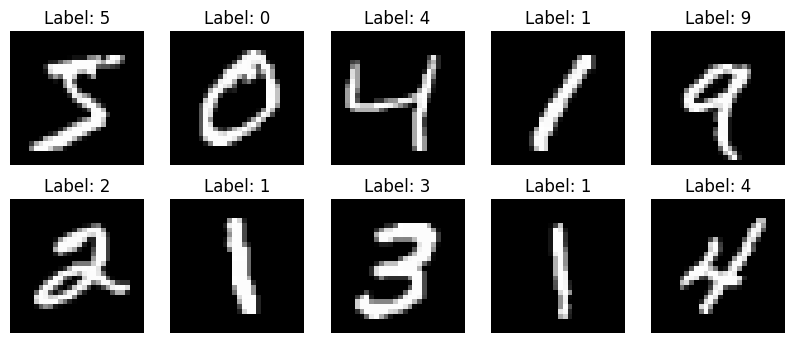

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8849 - loss: 0.3962 - val_accuracy: 0.9483 - val_loss: 0.1734
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9532 - loss: 0.1518 - val_accuracy: 0.9669 - val_loss: 0.1158
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9695 - loss: 0.1002 - val_accuracy: 0.9757 - val_loss: 0.0840
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.0742 - val_accuracy: 0.9769 - val_loss: 0.0815
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0580 - val_accuracy: 0.9801 - val_loss: 0.0695
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9850 - loss: 0.0494 - val_accuracy: 0.9805 - val_loss: 0.0659
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9873 - loss: 0.0407 - val_accuracy: 0.9817 - val_loss: 0.0612
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0

In [2]:
#Import Necessary Libraries
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Visualize The Training Data

plt.figure(figsize=(10, 4))  # Set The size Of The Figure
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Make subplots for 10 images
    plt.imshow(x_train[i], cmap='gray')  # Display The grayscale images
    plt.title(f"Label: {y_train[i]}")  # Add labels
    plt.axis('off')  # Axis Labels Turned Off
plt.show()  # Displaying the plot


#Data Processing
#Split The Data Into Training And Validation Set
#Here, we will split the data into the training and validation set.

# Consider The First 50000 samples As The Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

# Conside The Last 10000 Samples AS The Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]


#Normalize the Data
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

#Reshape data
#Change the shape of the arrays to include the color channel of the images. Since the images are grayscale, the color channel is 1.


x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


#One Hot Encoding
#Perform one-hot encoding to convert categorical data into binary vectors.
#Each element in the binary vector corresponds to a class, and only one element is 1, while the rest are 0.
#For example, if there are 10 classes and the label is 3, the one-hot encoded vector would be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)



#Build LeNet5 Model
#Create An Instance of Sequential Class.
LeNet5_Model=Sequential()

# Add First Convolutional Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# Add First Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Add Second Convolutional Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# Add Second Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Flatten The Layer
LeNet5_Model.add(Flatten())

# Add Dense Layer
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

#Compile The Model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


#Check Model Summary
LeNet5_Model.summary()


#Train The Model
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))


#Evaluate The Model Performance On The Test Dataset
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)







11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


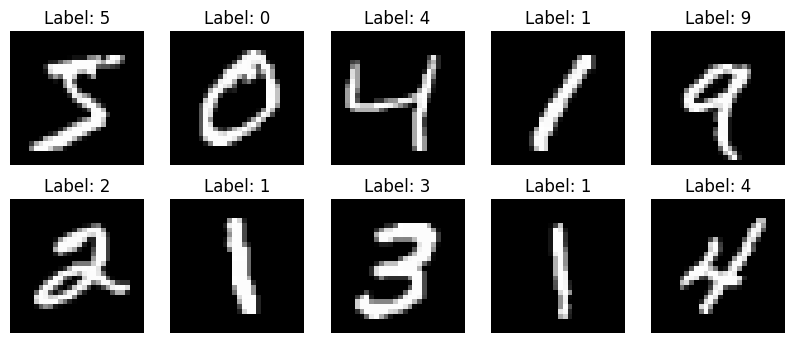

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8861 - loss: 0.3921 - precision: 0.9381 - recall: 0.8332 - val_accuracy: 0.9496 - val_loss: 0.1705 - val_precision: 0.9619 - val_recall: 0.9393
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9553 - loss: 0.1469 - precision: 0.9647 - recall: 0.9476 - val_accuracy: 0.9657 - val_loss: 0.1137 - val_precision: 0.9715 - val_recall: 0.9610
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9709 - loss: 0.0956 - precision: 0.9764 - recall: 0.9664 - val_accuracy: 0.9742 - val_loss: 0.0843 - val_precision: 0.9788 - val_recall: 0.9711
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9781 - loss: 0.0721 - precision: 0.9814 - recall: 0.9752 - val_accuracy: 0.9781 - val_loss: 0.0694 - val_precision: 0.9812 - val_recall: 0.9763
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9827 - loss: 0.0574 - precision: 0.9851 - recall: 0.9804 - val_accuracy: 0.9792 - val_loss: 

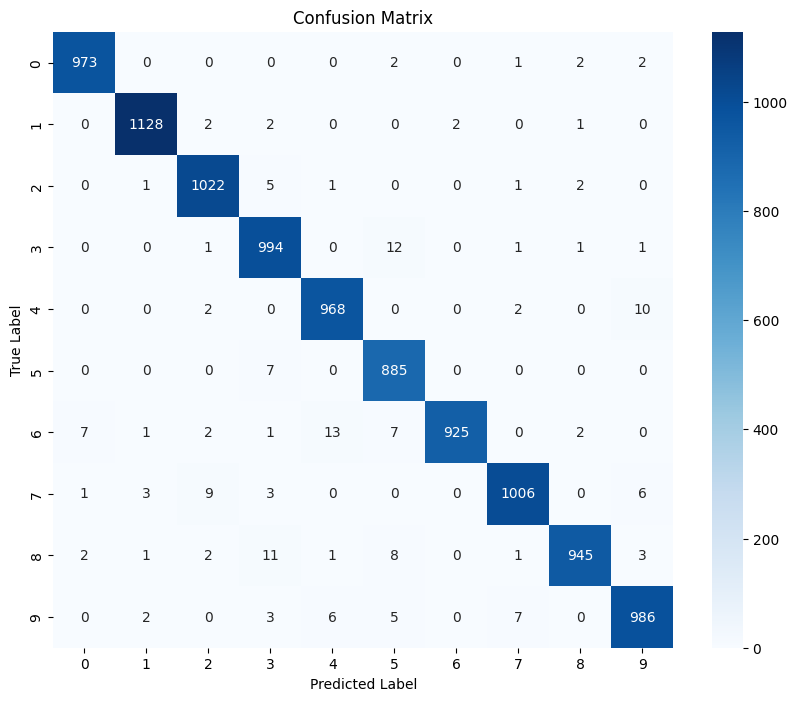

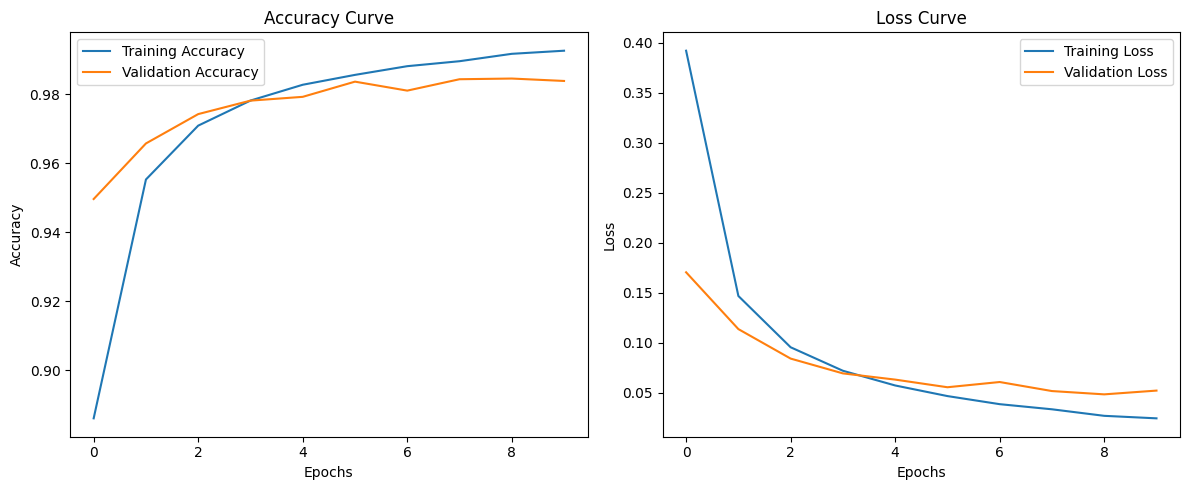

In [1]:
# Import Necessary Libraries
import keras
import keras.utils
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Visualize The Training Data
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# Split Data Into Training And Validation Set
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# Normalize The Data
x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Reshape Data
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# Save original labels before one-hot encoding for later analysis
y_train_labels = y_train_main.copy()
y_val_labels = y_val.copy()
y_test_labels = y_test.copy()

# One Hot Encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Build LeNet5 Model
LeNet5_Model = Sequential()

LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 28, 1)[1:]))
LeNet5_Model.add(AveragePooling2D((2, 2)))

LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
LeNet5_Model.add(AveragePooling2D((2, 2)))

LeNet5_Model.add(Flatten())
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

# Compile Model with more metrics
LeNet5_Model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)

# Check Model Summary
LeNet5_Model.summary()

# Train The Model
history = LeNet5_Model.fit(
    x_train_main,
    y_train_main,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# Evaluate On Test Dataset
test_loss, test_acc, test_precision, test_recall = LeNet5_Model.evaluate(x_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

# Predictions
y_pred_probs = LeNet5_Model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Additional Performance Metrics
print("\nSklearn Accuracy:", accuracy_score(y_test_labels, y_pred))
print("Weighted Precision:", precision_score(y_test_labels, y_pred, average='weighted'))
print("Weighted Recall:", recall_score(y_test_labels, y_pred, average='weighted'))
print("Weighted F1 Score:", f1_score(y_test_labels, y_pred, average='weighted'))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_labels, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
# Visualize outputs of Conv and Pooling layers only
for i, activation in enumerate(activations):
    layer_name = LeNet5_Model.layers[i].name

    # Only visualize 4D outputs (Conv and Pool layers)
    if len(activation.shape) == 4:
        num_filters = activation.shape[-1]

        plt.figure(figsize=(15, 5))
        plt.suptitle(f"Layer: {layer_name}", fontsize=16)

        for j in range(min(num_filters, 6)):  # show first 6 feature maps
            plt.subplot(1, min(num_filters, 6), j + 1)
            plt.imshow(activation[0, :, :, j], cmap='gray')
            plt.axis('off')
            plt.title(f"F{j+1}")

        plt.show()
        plt.show()

NameError: name 'activations' is not defined

In [5]:
# Visualize outputs of Conv and Pooling layers only
for i, activation in enumerate(activations):
    layer_name = LeNet5_Model.layers[i].name

    # Conv and Pool layers usually have 4D outputs
    if len(activation.shape) == 4:
        num_filters = activation.shape[-1]
        num_to_show = min(num_filters, 6)

        plt.figure(figsize=(15, 5))
        plt.suptitle(f"Layer: {layer_name}", fontsize=16)

        for j in range(num_to_show):
            plt.subplot(1, num_to_show, j + 1)
            plt.imshow(activation[0, :, :, j], cmap='gray')
            plt.axis('off')
            plt.title(f"F{j+1}")

        plt.tight_layout()
        plt.show()

NameError: name 'activations' is not defined

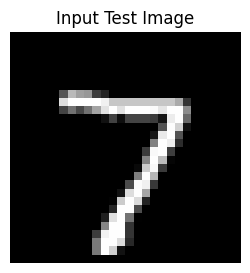

AttributeError: The layer sequential_1 has never been called and thus has no defined input.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model

# Choose one test image
sample_image = x_test[0]

# Display the input image
plt.figure(figsize=(3,3))
plt.imshow(sample_image.reshape(28,28), cmap='gray')
plt.title("Input Test Image")
plt.axis('off')
plt.show()

# Add batch dimension
sample_input = np.expand_dims(sample_image, axis=0)

# Create intermediate model
layer_outputs = [layer.output for layer in LeNet5_Model.layers]
activation_model = Model(inputs=LeNet5_Model.input, outputs=layer_outputs)

# Predict outputs of all layers
activations = activation_model.predict(sample_input)

# Print layer names and output shapes
print("\n===== OUTPUT SHAPE OF EACH LAYER =====\n")
for i, activation in enumerate(activations):
    print(f"Layer {i+1}: {LeNet5_Model.layers[i].name}")
    print("Output shape:", activation.shape)
    print("-" * 50)

# Visualize Conv and Pool layer outputs
print("\n===== VISUALIZING CONVOLUTION AND POOLING LAYERS =====\n")
for i, activation in enumerate(activations):
    layer_name = LeNet5_Model.layers[i].name

    # Conv and Pool layers have 4D outputs
    if len(activation.shape) == 4:
        num_filters = activation.shape[-1]

        plt.figure(figsize=(15, 5))
        plt.suptitle(f"Feature Maps - {layer_name}", fontsize=16)

        for j in range(min(num_filters, 6)):  # show first 6 filters
            plt.subplot(1, min(num_filters, 6), j + 1)
            plt.imshow(activation[0, :, :, j], cmap='gray')
            plt.axis('off')
            plt.title(f"F{j+1}")

        plt.show()

# Print Flatten and Dense outputs
print("\n===== FLATTEN / DENSE LAYER OUTPUTS =====\n")
for i, activation in enumerate(activations):
    layer_name = LeNet5_Model.layers[i].name

    # Flatten and Dense layers have 2D outputs
    if len(activation.shape) == 2:
        print(f"\nLayer: {layer_name}")
        print("Output shape:", activation.shape)
        print("First 20 values:", activation[0][:20])
        print("-" * 50)


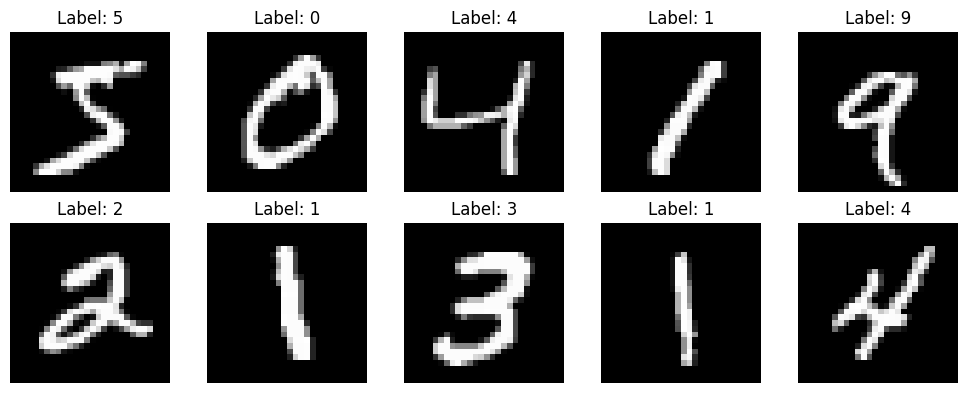

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling2D)     │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling2D)     │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8821 - loss: 0.4036 - val_accuracy: 0.9450 - val_loss: 0.1840
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9552 - loss: 0.1521 - val_accuracy: 0.9683 - val_loss: 0.1123
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9703 - loss: 0.1006 - val_accuracy: 0.9736 - val_loss: 0.0880
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.0745 - val_accuracy: 0.9756 - val_loss: 0.0816
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0609 - val_accuracy: 0.9791 - val_loss: 0.0728
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9851 - loss: 0.0493 - val_accuracy: 0.9820 - val_loss: 0.0631
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9872 - loss: 0.0410 - val_accuracy: 0.9807 - val_loss: 0.0613
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9896 - loss: 0.0342 - val_accuracy: 0.

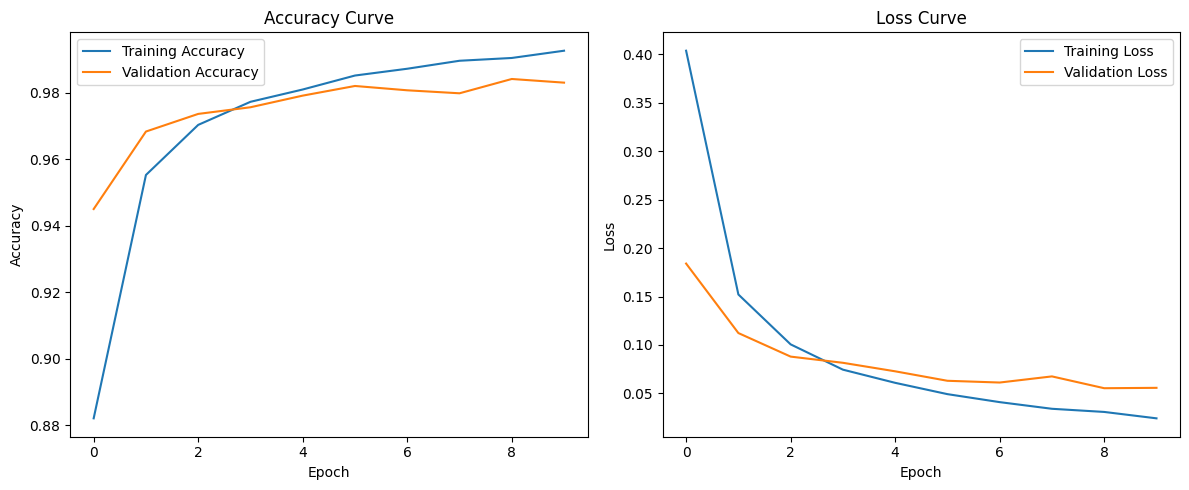

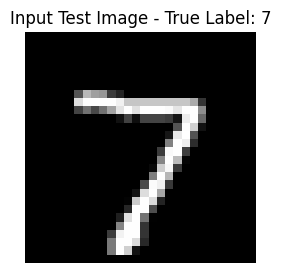

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step

===== OUTPUT SHAPES OF EACH LAYER =====

Layer 1: conv1
Output shape: (1, 24, 24, 6)
--------------------------------------------------
Layer 2: avgpool1
Output shape: (1, 12, 12, 6)
--------------------------------------------------
Layer 3: conv2
Output shape: (1, 8, 8, 16)
--------------------------------------------------
Layer 4: avgpool2
Output shape: (1, 4, 4, 16)
--------------------------------------------------
Layer 5: flatten
Output shape: (1, 256)
--------------------------------------------------
Layer 6: fc1
Output shape: (1, 120)
--------------------------------------------------
Layer 7: fc2
Output shape: (1, 84)
--------------------------------------------------
Layer 8: output
Output shape: (1, 10)
--------------------------------------------------

===== VISUALIZING CONVOLUTION AND POOLING LAYER OUTPUTS =====



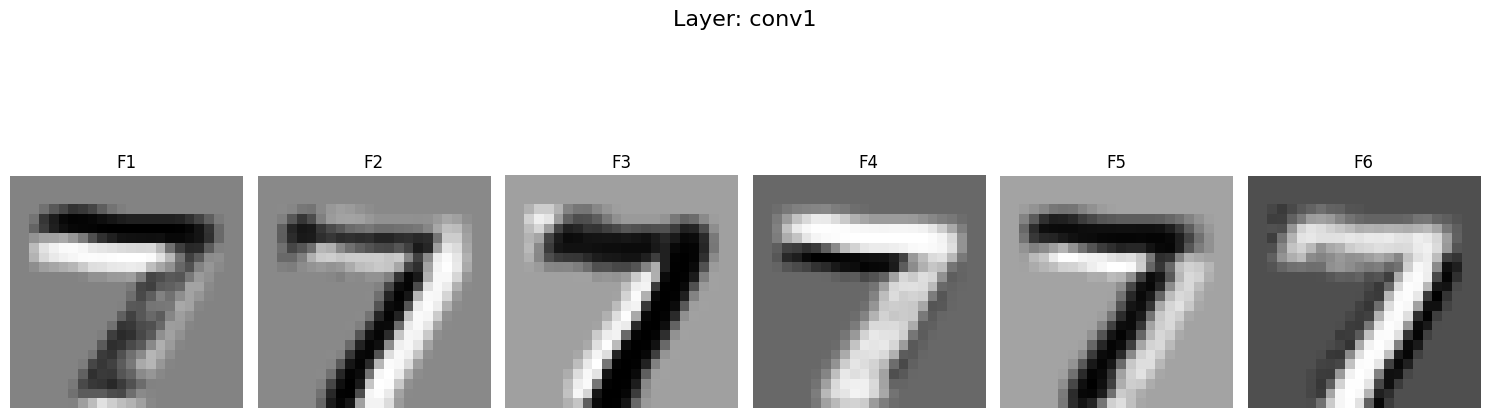

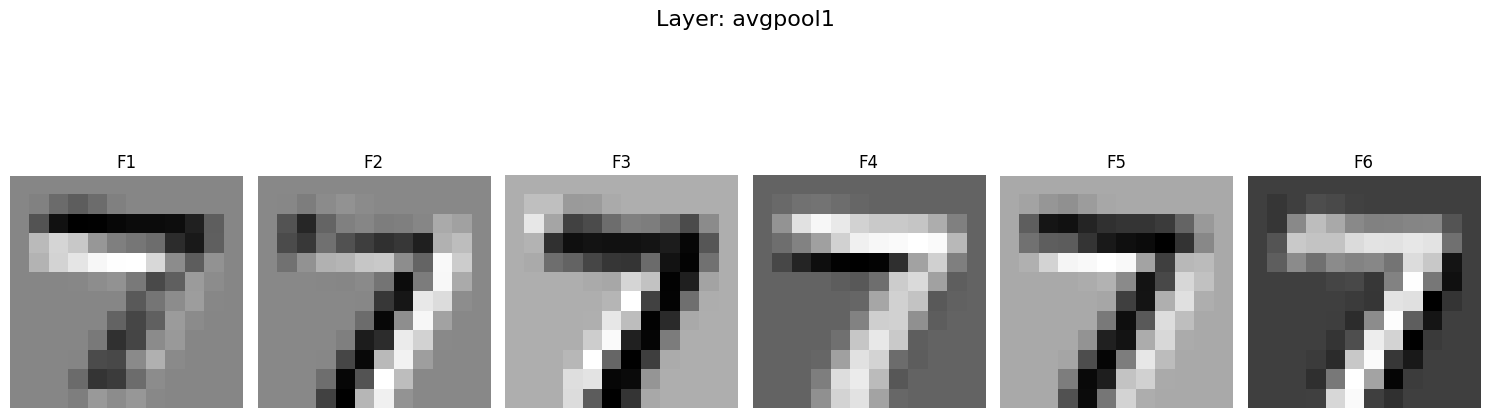

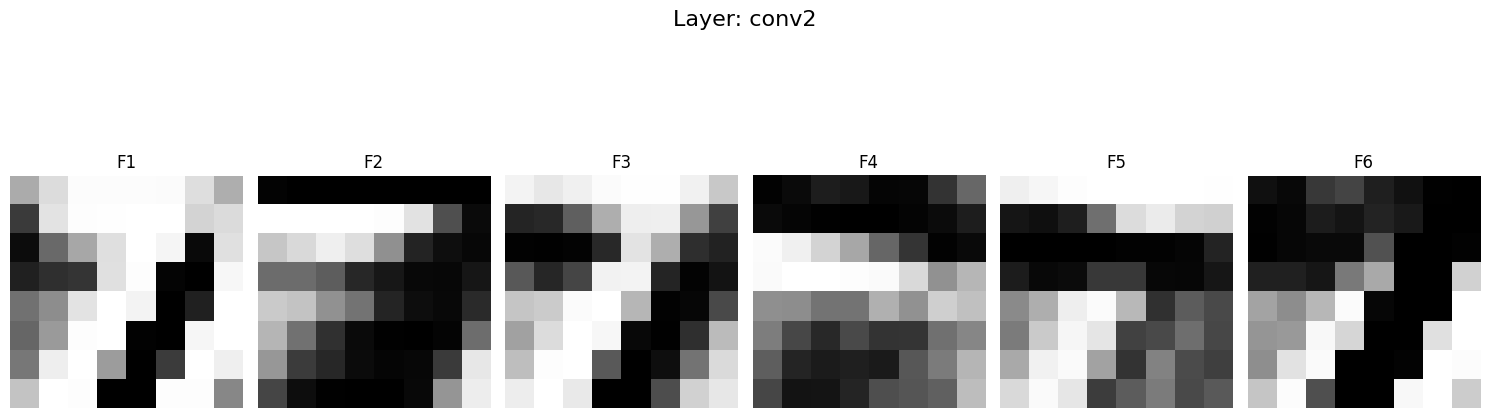

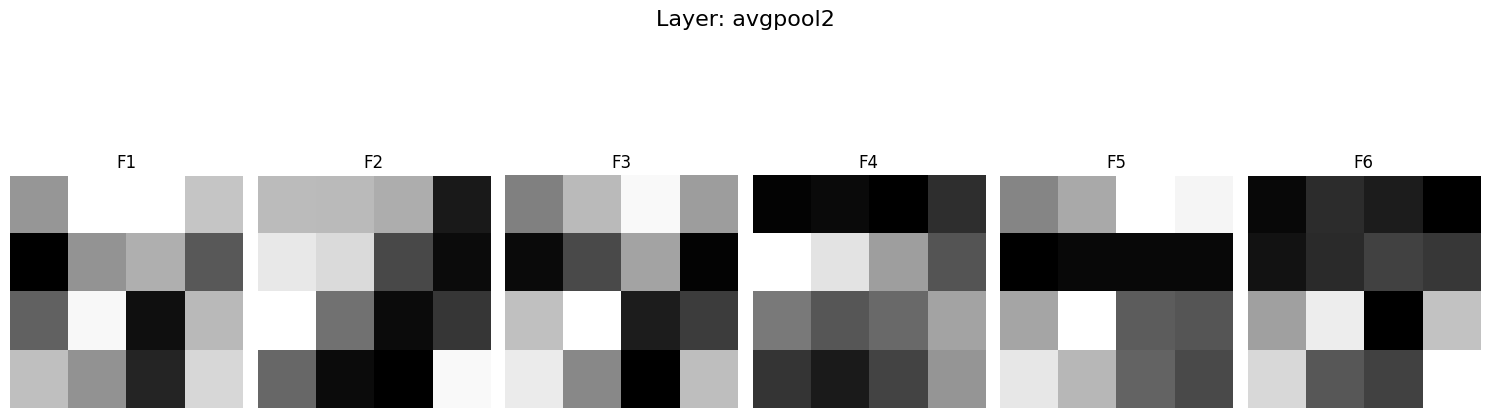


===== FLATTEN / DENSE LAYER OUTPUTS =====

Layer: flatten
Output shape: (1, 256)
First 20 values: [ 0.32538918  0.00600941  0.08450279 -0.9337479   0.02198581 -0.93552566
 -0.49200255 -0.96032023  0.1774147   0.3533502   0.82309264  0.6776975
 -0.8814074   0.01735185 -0.34692982  0.57526827  0.9778621  -0.0010145
  0.48862344 -0.8814237 ]
--------------------------------------------------
Layer: fc1
Output shape: (1, 120)
First 20 values: [ 0.99859035 -0.99939215 -0.8370305   0.99979556 -0.99762833 -0.94274443
 -0.6776366   0.925838   -0.7645845  -0.9845966   0.99707836  0.94035083
  0.9345413  -0.774515    0.8046898   0.9930176   0.09090261 -0.8848856
 -0.9108775  -0.999941  ]
--------------------------------------------------
Layer: fc2
Output shape: (1, 84)
First 20 values: [-0.99612385  0.60582465 -0.47070712  0.97955424  0.49961463 -0.8925112
  0.02820301 -0.8762634  -0.99815375  0.97276014  0.20149016  0.9158493
 -0.71667886 -0.96709216  0.71995294 -0.08053652 -0.8403959  -0.868

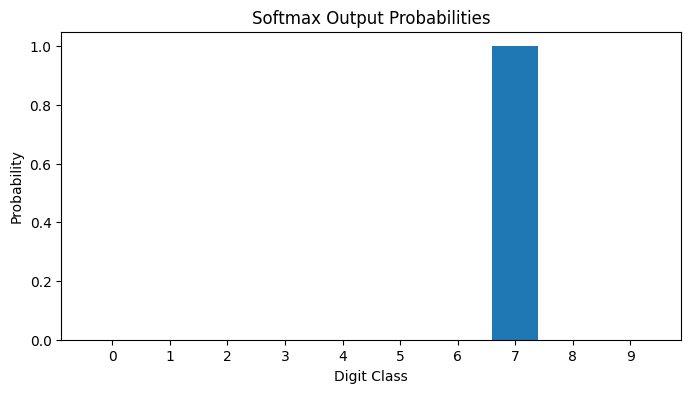

In [7]:
# =========================
# FULL LeNet-5 CODE
# with:
# 1. MNIST loading
# 2. preprocessing
# 3. model training
# 4. test evaluation
# 5. output of each layer
# 6. visualization of conv/pool feature maps
# =========================

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import datasets, Input
from keras.models import Sequential, Model
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# -------------------------
# 1. LOAD DATASET
# -------------------------
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# -------------------------
# 2. VISUALIZE SOME TRAINING IMAGES
# -------------------------
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# -------------------------
# 3. SPLIT INTO TRAIN + VALIDATION
# -------------------------
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# save original labels for later use if needed
y_test_labels = y_test.copy()

# -------------------------
# 4. NORMALIZE DATA
# -------------------------
x_train_main = x_train_main.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# -------------------------
# 5. RESHAPE DATA
# -------------------------
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# -------------------------
# 6. ONE HOT ENCODING
# -------------------------
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# -------------------------
# 7. BUILD LeNet-5 MODEL
# -------------------------
LeNet5_Model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(6, kernel_size=(5, 5), activation='tanh', name='conv1'),
    AveragePooling2D((2, 2), name='avgpool1'),
    Conv2D(16, kernel_size=(5, 5), activation='tanh', name='conv2'),
    AveragePooling2D((2, 2), name='avgpool2'),
    Flatten(name='flatten'),
    Dense(120, activation='tanh', name='fc1'),
    Dense(84, activation='tanh', name='fc2'),
    Dense(10, activation='softmax', name='output')
])

# -------------------------
# 8. COMPILE MODEL
# -------------------------
LeNet5_Model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# -------------------------
# 9. MODEL SUMMARY
# -------------------------
LeNet5_Model.summary()

# -------------------------
# 10. TRAIN MODEL
# -------------------------
history = LeNet5_Model.fit(
    x_train_main,
    y_train_main,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# -------------------------
# 11. EVALUATE MODEL
# -------------------------
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

# -------------------------
# 12. PLOT TRAINING / VALIDATION ACCURACY AND LOSS
# -------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------
# 13. SELECT ONE TEST IMAGE
# -------------------------
sample_index = 0
sample_image = x_test[sample_index]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"Input Test Image - True Label: {y_test_labels[sample_index]}")
plt.axis('off')
plt.show()

# add batch dimension
sample_input = np.expand_dims(sample_image, axis=0)

# -------------------------
# 14. CREATE INTERMEDIATE MODEL
# -------------------------
layer_outputs = [layer.output for layer in LeNet5_Model.layers]
activation_model = Model(inputs=LeNet5_Model.inputs, outputs=layer_outputs)

# -------------------------
# 15. GET OUTPUT OF EACH LAYER
# -------------------------
activations = activation_model.predict(sample_input)

print("\n===== OUTPUT SHAPES OF EACH LAYER =====\n")
for i, activation in enumerate(activations):
    print(f"Layer {i+1}: {LeNet5_Model.layers[i].name}")
    print("Output shape:", activation.shape)
    print("-" * 50)

# -------------------------
# 16. VISUALIZE CONV AND POOL LAYER OUTPUTS
# -------------------------
print("\n===== VISUALIZING CONVOLUTION AND POOLING LAYER OUTPUTS =====\n")

for i, activation in enumerate(activations):
    layer_name = LeNet5_Model.layers[i].name

    # Conv and pooling outputs are 4D: (batch, height, width, channels)
    if len(activation.shape) == 4:
        num_filters = activation.shape[-1]
        num_to_show = min(num_filters, 6)

        plt.figure(figsize=(15, 5))
        plt.suptitle(f"Layer: {layer_name}", fontsize=16)

        for j in range(num_to_show):
            plt.subplot(1, num_to_show, j + 1)
            plt.imshow(activation[0, :, :, j], cmap='gray')
            plt.axis('off')
            plt.title(f"F{j+1}")

        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.show()

# -------------------------
# 17. PRINT FLATTEN AND DENSE LAYER OUTPUTS
# -------------------------
print("\n===== FLATTEN / DENSE LAYER OUTPUTS =====\n")

for i, activation in enumerate(activations):
    layer_name = LeNet5_Model.layers[i].name

    # Flatten and dense outputs are 2D: (batch, neurons)
    if len(activation.shape) == 2:
        print(f"Layer: {layer_name}")
        print("Output shape:", activation.shape)
        print("First 20 values:", activation[0][:20])
        print("-" * 50)

# -------------------------
# 18. FINAL PREDICTION FOR SAMPLE IMAGE
# -------------------------
final_output = activations[-1]
predicted_class = np.argmax(final_output)
predicted_prob = np.max(final_output)

print("\n===== FINAL PREDICTION =====")
print("True Label     :", y_test_labels[sample_index])
print("Predicted Label:", predicted_class)
print("Confidence     :", predicted_prob)

# show class probabilities
plt.figure(figsize=(8, 4))
plt.bar(range(10), final_output[0])
plt.xticks(range(10))
plt.xlabel("Digit Class")
plt.ylabel("Probability")
plt.title("Softmax Output Probabilities")
plt.show()